In this notebook we will create a large custom model, going to the limits of the hardware we have (a single RTX 3050 Ti Laptop GPU, with 4GB of VRAM)

First let's import the libraries, check if our GPU is recognized and create the image datasets

## TODO: We need to add a test dataset and an evaluation section at the end of each of the models we created here

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TensorFlow warnings

import numpy as np
import keras
from keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt

Let's check if our GPU is recognized and set the VRAM limit for tensorflow to reserve

In [21]:
gpus = tf.config.list_physical_devices('GPU')
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [22]:
# 16GB Tesla T4 (Google Colab)
# 4GB RTX 3050 Ti Laptop (Afonso)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
    tf.config.set_logical_device_configuration(
        gpu,
        [tf.config.LogicalDeviceConfiguration(memory_limit=3584)]
    )

ValueError: Cannot set memory growth on device when virtual devices configured

In [ ]:
tf.config.experimental.get_memory_info('GPU:0')

I0000 00:00:1775318887.920050  185968 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3584 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


{'current': 0, 'peak': 0}

As our model architecture will be a smaller version of VGG16, let's try to use half of it's resolution, so 224/2 = 112

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
DATA_PATH = "../data"
# DATA_PATH = "drive/MyDrive/Colab Notebooks/WikiArt/wikiart_datasets"

image_size = (112, 112) # the original images are 512x512 but we resize them to save memory while training
batch_size = 32
n_classes = 23

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    DATA_PATH,
    image_size=image_size,
    batch_size=batch_size,
    seed=255, # for reproducibility
    validation_split=0.2,
    subset="both",
    label_mode="categorical"
)

Found 13340 files belonging to 23 classes.
Using 10672 files for training.
Using 2668 files for validation.


Let's now create our large model following the architecture of VGG16 but with a much smaller size so that we can train it locally

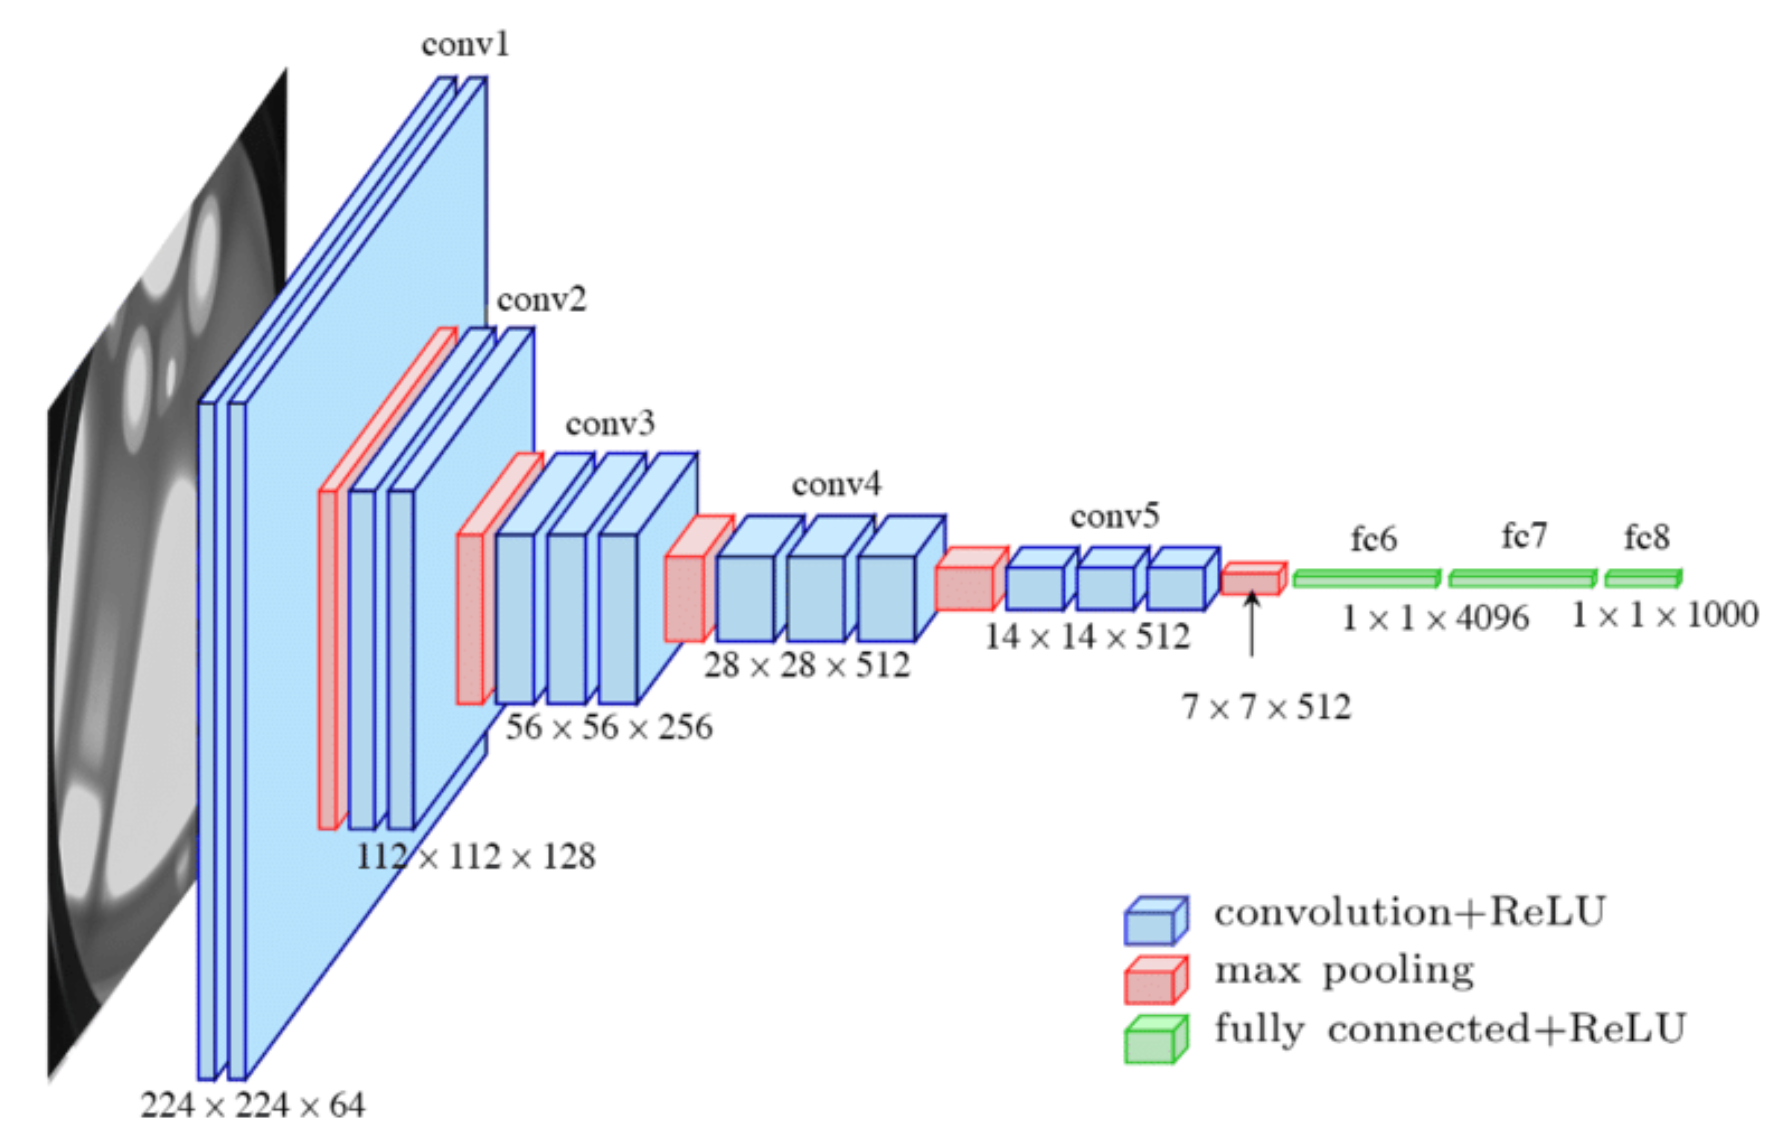

In [ ]:
model = keras.Sequential()
model.add(keras.Input(shape=image_size + (3,)))
model.add(layers.Rescaling(1./255)) # standardize RGB values to 0-1 range

model.add(layers.Conv2D(8, 3, activation="relu", padding="same"))
model.add(layers.Conv2D(8, 3, activation="relu", padding="same"))
model.add(layers.MaxPooling2D(2))

model.add(layers.Conv2D(16, 3, activation="relu", padding="same"))
model.add(layers.Conv2D(16, 3, activation="relu", padding="same"))
model.add(layers.MaxPooling2D(2))

model.add(layers.Conv2D(32, 3, activation="relu", padding="same"))
model.add(layers.Conv2D(32, 3, activation="relu", padding="same"))
model.add(layers.Conv2D(32, 3, activation="relu", padding="same"))
model.add(layers.MaxPooling2D(2))

model.add(layers.Conv2D(64, 3, activation="relu", padding="same"))
model.add(layers.Conv2D(64, 3, activation="relu", padding="same"))
model.add(layers.Conv2D(64, 3, activation="relu", padding="same"))
model.add(layers.MaxPooling2D(2))

model.add(layers.Conv2D(64, 3, activation="relu", padding="same"))
model.add(layers.Conv2D(64, 3, activation="relu", padding="same"))
model.add(layers.Conv2D(64, 3, activation="relu", padding="same"))
model.add(layers.MaxPooling2D(2))

model.add(layers.Flatten())

model.add(layers.Dense(256, activation="relu"))
model.add(layers.Dense(n_classes, activation="softmax"))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 112, 112, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 8)    │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 384,191 (1.47 MB)

 Trainable params: 384,191 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1e-3, momentum=0.9, weight_decay=1e-5), # use the same optimizer as VGG16
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='weighted'),
        keras.metrics.AUC(multi_label=True, num_labels=n_classes)
    ]
)

In [47]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", patience=3)
)

Epoch 1/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - auc_6: 0.4995 - categorical_accuracy: 0.0941 - f1_score: 0.0328 - loss: 3.0965 - val_auc_6: 0.5040 - val_categorical_accuracy: 0.1001 - val_f1_score: 0.0182 - val_loss: 3.0497
Epoch 2/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - auc_6: 0.5186 - categorical_accuracy: 0.0997 - f1_score: 0.0325 - loss: 3.0403 - val_auc_6: 0.5419 - val_categorical_accuracy: 0.1076 - val_f1_score: 0.0311 - val_loss: 3.0336
Epoch 3/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - auc_6: 0.5497 - categorical_accuracy: 0.1079 - f1_score: 0.0353 - loss: 3.0223 - val_auc_6: 0.5950 - val_categorical_accuracy: 0.1181 - val_f1_score: 0.0375 - val_loss: 3.0020
Epoch 4/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - auc_6: 0.5960 - categorical_accuracy: 0.1315 - f1_score: 0.0624 - loss: 2.9632 - val_auc_6: 0.6302 - val_categorical_accuracy: 0.1436 - val_f1_score: 0.0642 - val_loss: 2.9574
Epoch 5/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - auc_6: 0.6341 - cate

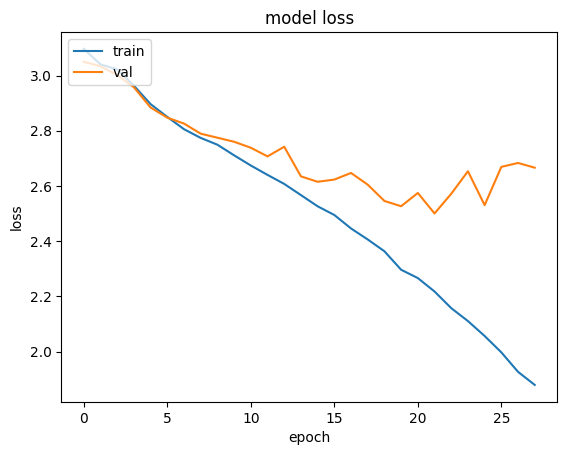

In [48]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

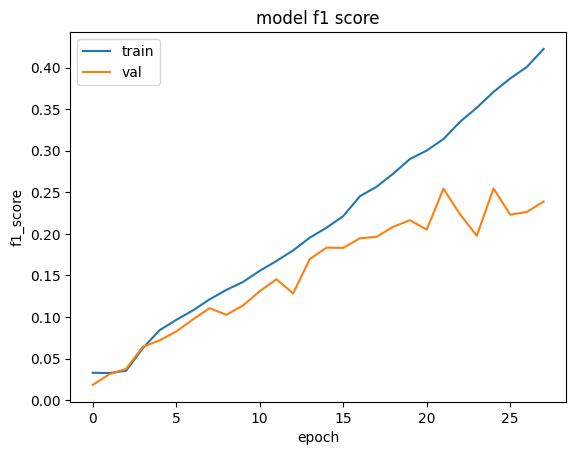

In [49]:
plt.plot(history.history['f1_score'])
plt.plot(history.history['val_f1_score'])
plt.title('model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Let's now try the same model but with the Adam optimizer

In [66]:
model_adam = keras.models.clone_model(model)

In [67]:
model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='weighted'),
        keras.metrics.AUC(multi_label=True, num_labels=n_classes)
    ]
)

In [68]:
history_adam = model_adam.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", patience=3)
)

Epoch 1/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - auc_10: 0.5337 - categorical_accuracy: 0.1089 - f1_score: 0.0438 - loss: 3.0355 - val_auc_10: 0.6349 - val_categorical_accuracy: 0.1327 - val_f1_score: 0.0444 - val_loss: 2.9461
Epoch 2/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - auc_10: 0.6747 - categorical_accuracy: 0.1794 - f1_score: 0.1181 - loss: 2.8124 - val_auc_10: 0.7210 - val_categorical_accuracy: 0.2091 - val_f1_score: 0.1418 - val_loss: 2.7005
Epoch 3/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - auc_10: 0.7401 - categorical_accuracy: 0.2283 - f1_score: 0.1805 - loss: 2.6214 - val_auc_10: 0.7502 - val_categorical_accuracy: 0.2215 - val_f1_score: 0.1630 - val_loss: 2.6160
Epoch 4/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - auc_10: 0.7721 - categorical_accuracy: 0.2643 - f1_score: 0.2241 - loss: 2.5048 - val_auc_10: 0.7791 - val_categorical_accuracy: 0.2594 - val_f1_score: 0.2135 - val_loss: 2.4904
Epoch 5/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - auc_10: 0.79

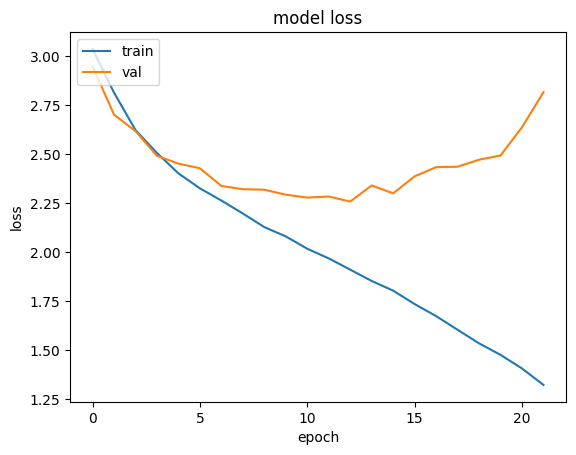

In [69]:
plt.plot(history_adam.history['loss'])
plt.plot(history_adam.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

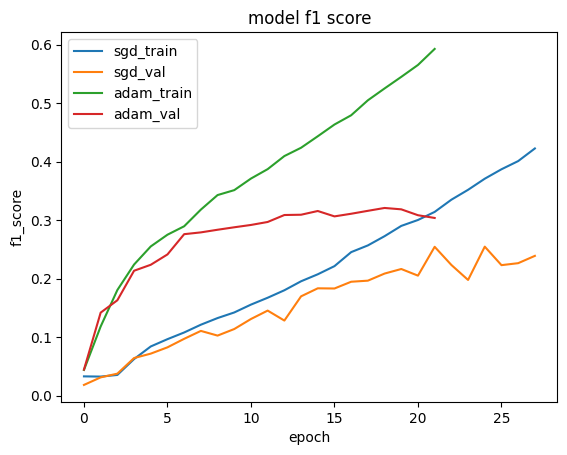

In [94]:
plt.plot(history.history['f1_score'])
plt.plot(history.history['val_f1_score'])
plt.plot(history_adam.history['f1_score'])
plt.plot(history_adam.history['val_f1_score'])
plt.title('model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['sgd_train', 'sgd_val', 'adam_train', 'adam_val'], loc='upper left')
plt.show()

Using the Adam optimizer gave us much better results than our manual SGD tuning, and it was also faster to converge. 

We just had to decrease the learning rate from 1e-3 to 1e-4 because it was not converging.

Let's now train the same model but with the AdamW optimizer

In [91]:
model_adamw = keras.models.clone_model(model)

In [92]:
model_adamw.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-2),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='weighted'),
        keras.metrics.AUC(multi_label=True, num_labels=n_classes)
    ]
)

In [93]:
history_adamw = model_adamw.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", patience=3)
)

Epoch 1/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - auc_16: 0.5421 - categorical_accuracy: 0.1021 - f1_score: 0.0456 - loss: 3.0322 - val_auc_16: 0.6353 - val_categorical_accuracy: 0.1552 - val_f1_score: 0.0689 - val_loss: 2.9309
Epoch 2/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - auc_16: 0.6672 - categorical_accuracy: 0.1644 - f1_score: 0.1008 - loss: 2.8350 - val_auc_16: 0.6874 - val_categorical_accuracy: 0.1724 - val_f1_score: 0.1033 - val_loss: 2.8039
Epoch 3/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - auc_16: 0.7129 - categorical_accuracy: 0.1927 - f1_score: 0.1366 - loss: 2.7286 - val_auc_16: 0.7096 - val_categorical_accuracy: 0.1904 - val_f1_score: 0.1362 - val_loss: 2.7473
Epoch 4/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - auc_16: 0.7445 - categorical_accuracy: 0.2218 - f1_score: 0.1776 - loss: 2.6244 - val_auc_16: 0.7423 - val_categorical_accuracy: 0.2324 - val_f1_score: 0.1730 - val_loss: 2.6319
Epoch 5/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - auc_16: 0.77

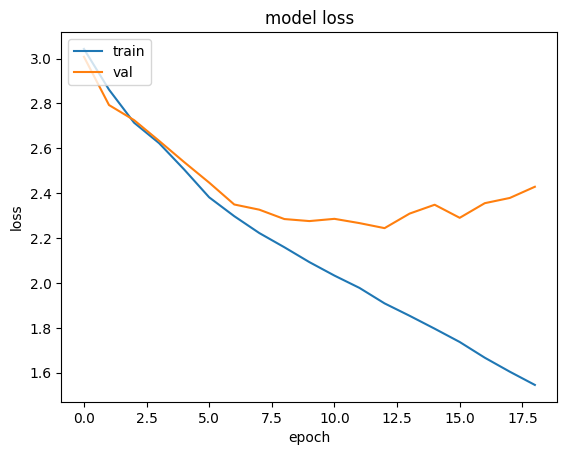

In [84]:
plt.plot(history_adamw.history['loss'])
plt.plot(history_adamw.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

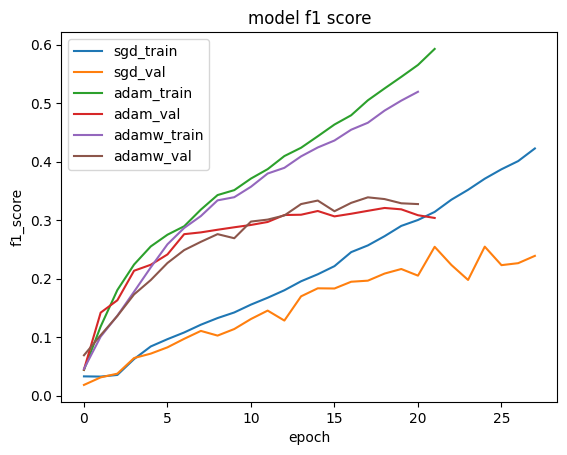

In [95]:
plt.plot(history.history['f1_score'])
plt.plot(history.history['val_f1_score'])
plt.plot(history_adam.history['f1_score'])
plt.plot(history_adam.history['val_f1_score'])
plt.plot(history_adamw.history['f1_score'])
plt.plot(history_adamw.history['val_f1_score'])
plt.title('model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['sgd_train', 'sgd_val', 'adam_train', 'adam_val', 'adamw_train', 'adamw_val'], loc='upper left')
plt.show()

Using the AdamW optimizer gave us comparable results to the normal Adam optimizer, with a little less overfitting. 

We tried 1e-3, 2e-3, 4e-3 (default) and 1e-2 and could not meaningfully improve results.

Now let's add image augmentation techniques to the start of the model, and train using AdamW

(future idea, maybe because RandAugment acts as a regularizer, maybe we don't need to use Adam or AdamW and could use SGD or even RMSprop, but it may require more manual fiddling)

In [96]:
model_rand_augment = keras.Sequential(
    [
        keras.Input(shape=image_size + (3,)),

        layers.RandAugment(),
        layers.Rescaling(1./255), # standardize RGB values to 0-1 range

        layers.Conv2D(8, 3, activation="relu", padding="same"),
        layers.Conv2D(8, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Conv2D(16, 3, activation="relu", padding="same"),
        layers.Conv2D(16, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(n_classes, activation="softmax")
    ]
)

In [97]:
model_rand_augment.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rand_augment (RandAugment)      │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 112, 112, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 112, 112, 8)    │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 56, 56, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 56, 56, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 56, 56, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 384,191 (1.47 MB)

 Trainable params: 384,191 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

In [99]:
model_rand_augment.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-2),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(average='weighted'),
        keras.metrics.AUC(multi_label=True, num_labels=n_classes)
    ]
)

In [100]:
history_rand_augment = model_rand_augment.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", patience=3)
)

Epoch 1/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 43s 88ms/step - auc_17: 0.5076 - categorical_accuracy: 0.0968 - f1_score: 0.0316 - loss: 3.0553 - val_auc_17: 0.5212 - val_categorical_accuracy: 0.1001 - val_f1_score: 0.0182 - val_loss: 3.0248
Epoch 2/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - auc_17: 0.5221 - categorical_accuracy: 0.1003 - f1_score: 0.0320 - loss: 3.0346 - val_auc_17: 0.5488 - val_categorical_accuracy: 0.1274 - val_f1_score: 0.0451 - val_loss: 3.0184
Epoch 3/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 29s 88ms/step - auc_17: 0.5697 - categorical_accuracy: 0.1287 - f1_score: 0.0556 - loss: 2.9961 - val_auc_17: 0.6505 - val_categorical_accuracy: 0.1383 - val_f1_score: 0.0643 - val_loss: 2.9027
Epoch 4/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 95ms/step - auc_17: 0.6399 - categorical_accuracy: 0.1587 - f1_score: 0.0934 - loss: 2.8753 - val_auc_17: 0.6976 - val_categorical_accuracy: 0.1784 - val_f1_score: 0.1013 - val_loss: 2.7710
Epoch 5/30
334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 96ms/step - auc_17: 

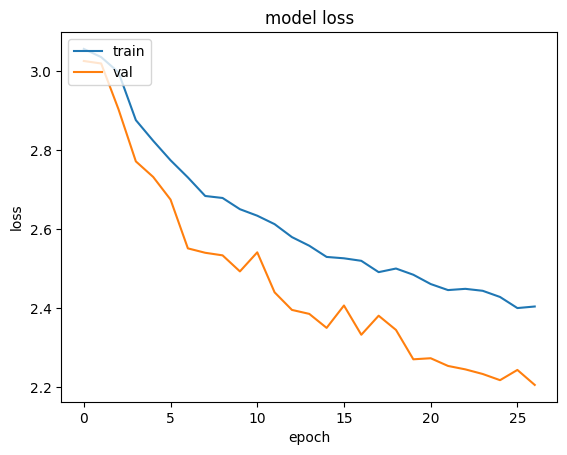

In [101]:
plt.plot(history_rand_augment.history['loss'])
plt.plot(history_rand_augment.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

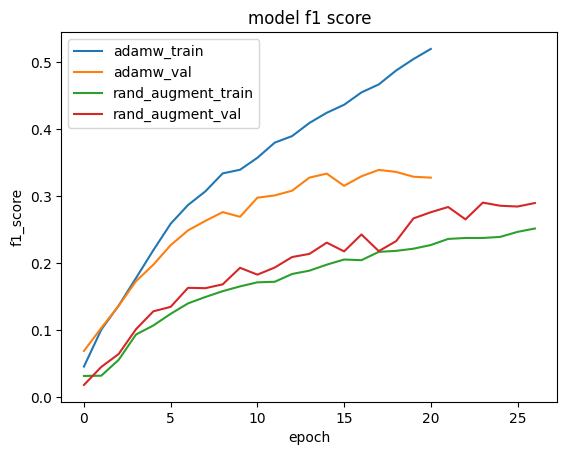

In [102]:
plt.plot(history_adamw.history['f1_score'])
plt.plot(history_adamw.history['val_f1_score'])
plt.plot(history_rand_augment.history['f1_score'])
plt.plot(history_rand_augment.history['val_f1_score'])
plt.title('model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['adamw_train', 'adamw_val','rand_augment_train', 'rand_augment_val', ], loc='upper left')
plt.show()

The model was still improving when it early stopped, let's continue training for some more epochs and maybe 

In [103]:
history_rand_augment_2 = model_rand_augment.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=27,
    epochs=37,
    # callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", patience=3)
)

Epoch 28/37
334/334 ━━━━━━━━━━━━━━━━━━━━ 30s 90ms/step - auc_17: 0.7919 - categorical_accuracy: 0.2696 - f1_score: 0.2426 - loss: 2.4334 - val_auc_17: 0.8450 - val_categorical_accuracy: 0.3257 - val_f1_score: 0.2924 - val_loss: 2.1931
Epoch 29/37
334/334 ━━━━━━━━━━━━━━━━━━━━ 30s 91ms/step - auc_17: 0.8027 - categorical_accuracy: 0.2722 - f1_score: 0.2484 - loss: 2.3968 - val_auc_17: 0.8427 - val_categorical_accuracy: 0.3167 - val_f1_score: 0.2710 - val_loss: 2.2341
Epoch 30/37
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - auc_17: 0.8020 - categorical_accuracy: 0.2815 - f1_score: 0.2574 - loss: 2.3895 - val_auc_17: 0.8488 - val_categorical_accuracy: 0.3381 - val_f1_score: 0.2977 - val_loss: 2.1653
Epoch 31/37
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 93ms/step - auc_17: 0.8011 - categorical_accuracy: 0.2805 - f1_score: 0.2556 - loss: 2.3950 - val_auc_17: 0.8410 - val_categorical_accuracy: 0.3272 - val_f1_score: 0.2923 - val_loss: 2.2173
Epoch 32/37
334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - auc

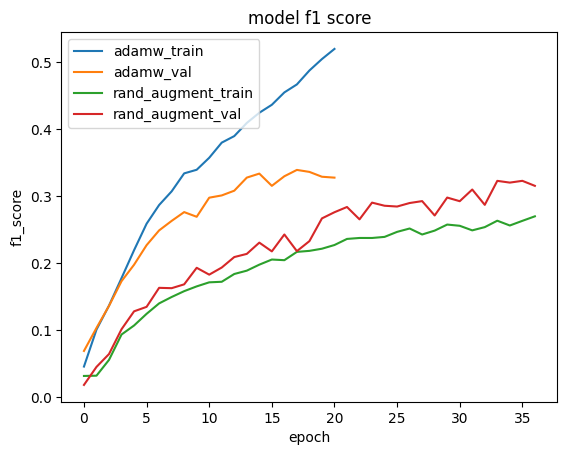

In [105]:
plt.plot(history_adamw.history['f1_score'])
plt.plot(history_adamw.history['val_f1_score'])
plt.plot(history_rand_augment.history['f1_score'] + history_rand_augment_2.history['f1_score'])
plt.plot(history_rand_augment.history['val_f1_score'] + history_rand_augment_2.history['val_f1_score'])
plt.title('model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['adamw_train', 'adamw_val','rand_augment_train', 'rand_augment_val', ], loc='upper left')
plt.show()

In [106]:
history_rand_augment_3 = model_rand_augment.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=37,
    epochs=100,
    callbacks=keras.callbacks.EarlyStopping(monitor="val_f1_score", patience=10, restore_best_weights=True)
)

Epoch 38/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 28s 84ms/step - auc_17: 0.8131 - categorical_accuracy: 0.2930 - f1_score: 0.2695 - loss: 2.3452 - val_auc_17: 0.8537 - val_categorical_accuracy: 0.3433 - val_f1_score: 0.3104 - val_loss: 2.1432
Epoch 39/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - auc_17: 0.8163 - categorical_accuracy: 0.2999 - f1_score: 0.2760 - loss: 2.3239 - val_auc_17: 0.8527 - val_categorical_accuracy: 0.3456 - val_f1_score: 0.3063 - val_loss: 2.1571
Epoch 40/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 28s 85ms/step - auc_17: 0.8142 - categorical_accuracy: 0.3027 - f1_score: 0.2794 - loss: 2.3259 - val_auc_17: 0.8565 - val_categorical_accuracy: 0.3606 - val_f1_score: 0.3263 - val_loss: 2.1203
Epoch 41/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - auc_17: 0.8218 - categorical_accuracy: 0.3037 - f1_score: 0.2812 - loss: 2.3039 - val_auc_17: 0.8519 - val_categorical_accuracy: 0.3497 - val_f1_score: 0.3203 - val_loss: 2.1663
Epoch 42/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 96ms/step 

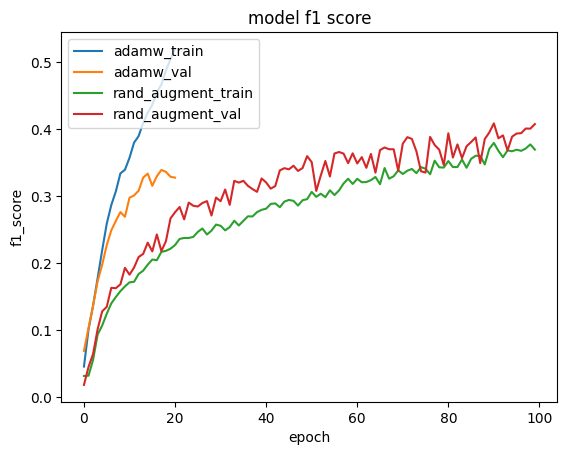

In [107]:
plt.plot(history_adamw.history['f1_score'])
plt.plot(history_adamw.history['val_f1_score'])
plt.plot(history_rand_augment.history['f1_score'] + history_rand_augment_2.history['f1_score'] + history_rand_augment_3.history['f1_score'])
plt.plot(history_rand_augment.history['val_f1_score'] + history_rand_augment_2.history['val_f1_score'] + history_rand_augment_3.history['val_f1_score'])
plt.title('model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['adamw_train', 'adamw_val','rand_augment_train', 'rand_augment_val', ], loc='upper left')
plt.show()

Based on the 100 epochs of training we have already done, let's extrapolate what would the performance be in 1000 epochs and evaluate if it is worth it

In [141]:
val_f1_score = history_rand_augment.history['val_f1_score'] \
    + history_rand_augment_2.history['val_f1_score'] \
    + history_rand_augment_3.history['val_f1_score']

epochs = range(len(val_f1_score))

# val f1 score follows a log shape, so we need to log the independent 
# variable x to transform into a linear relation and apply linear regression
z = np.polyfit(np.log1p(epochs), val_f1_score, 1)
p = np.poly1d(z)

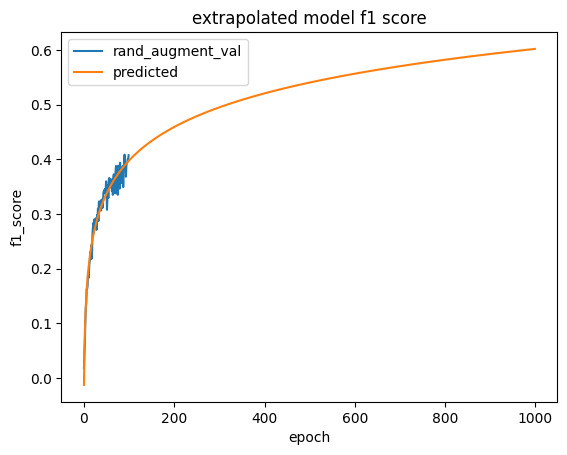

In [152]:
plt.plot(history_rand_augment.history['val_f1_score'] + history_rand_augment_2.history['val_f1_score'] + history_rand_augment_3.history['val_f1_score'])
plt.plot(p(np.log1p(range(1000))))
plt.title('extrapolated model f1 score')
plt.ylabel('f1_score')
plt.xlabel('epoch')
plt.legend(['rand_augment_val', 'predicted'], loc='upper left')
plt.show()

After 1000 epochs the predicted performance would be ~0.6 f1 score.

Taking into account each training epoch is taking ~32s, let's calculate how long it would take to train 1000 epochs

In [7]:
import datetime
str(datetime.timedelta(seconds=32*1000))

'8:53:20'

It would take almost 9 hours